In [2]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf

import seaborn as sns
from matplotlib import pyplot as plt

# fig4b

/tmp/ipykernel_3500442/3802875899.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='context', y='Changes(baseline-recall)',
/tmp/ipykernel_3500442/3802875899.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='context', y='Changes(baseline-recall)',
/tmp/ipykernel_3500442/3802875899.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylabel='correlation distance (baseline–recall)',
/tmp/ipykernel_3500442/3802875899.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylabel='correlation distance (b

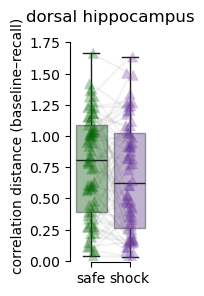

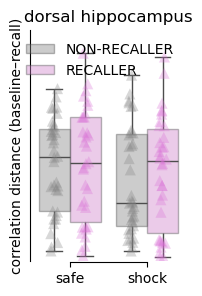

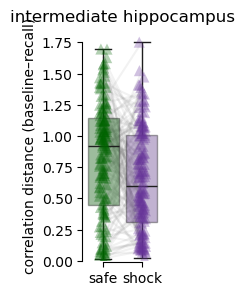

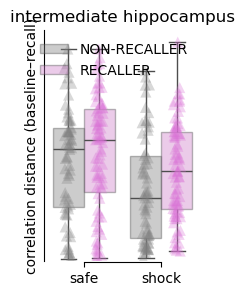

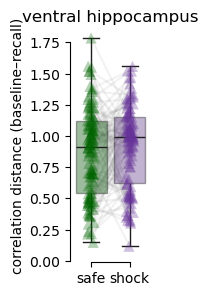

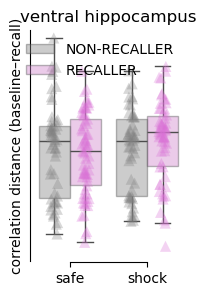

In [3]:
df_mds_ctx = pd.read_parquet('Fig4b.parquet')

for pole in ['dorsal', 'intermediate', 'ventral']:
    fig, ax = plt.subplots(1, 1, figsize=(1, 3))

    for l in np.array(df_mds_ctx.query("pole == '{}'".format(pole)).set_index(
        ['rat', 'cluster', 'context']).unstack()['Changes(baseline-recall)'][['ctrl', 'shock']]):
        
        ax.plot(l, color='gray', alpha=0.1)

    sns.boxplot(x='context', y='Changes(baseline-recall)',
                order=['ctrl', 'shock'],
                palette=['darkgreen', 'rebeccapurple'],
                boxprops=dict(alpha=0.4), fliersize=0.0,
                data=df_mds_ctx.query("pole == '{}'".format(pole)), ax=ax)
    sns.stripplot(x='context', y='Changes(baseline-recall)',
                  order=['ctrl', 'shock'],
                  palette=['darkgreen', 'rebeccapurple'],
                  size=8, alpha=0.3, dodge=False, marker='^',
                  data=df_mds_ctx.query("pole == '{}'".format(pole)), ax=ax)

    ax.set(ylabel='correlation distance (baseline–recall)',
           xlabel='', xticklabels=['safe', 'shock'],
           ylim=(0, 1.85),
           title='{} hippocampus'.format(pole))
    sns.despine(offset=True, trim=True)


    fig, ax = plt.subplots(1, 1, figsize=(2, 3))

    sns.boxplot(x='context', y='Changes(baseline-recall)',
                order=['ctrl', 'shock'],
                hue='context_learning', hue_order=['not learned', 'learned'],
                palette=['grey', 'orchid'],
                boxprops=dict(alpha=0.4), fliersize=0.0,
                data=df_mds_ctx.query("pole == '{}'".format(pole)), ax=ax)
    sns.stripplot(x='context', y='Changes(baseline-recall)',
                  order=['ctrl', 'shock'],
                  hue='context_learning', hue_order=['not learned', 'learned'],
                  palette=['grey', 'orchid'],
                  size=8, alpha=0.3, dodge=True, marker='^',
                  data=df_mds_ctx.query("pole == '{}'".format(pole)), ax=ax)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], ['NON-RECALLER', 'RECALLER'], frameon=False)
    ax.set(ylabel='correlation distance (baseline–recall)',
           yticks=[], xlabel='',
           xticklabels=['safe', 'shock'],
           ylim=(0, 1.85),
           title='{} hippocampus'.format(pole))
    sns.despine(offset=True, trim=True)

/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regre

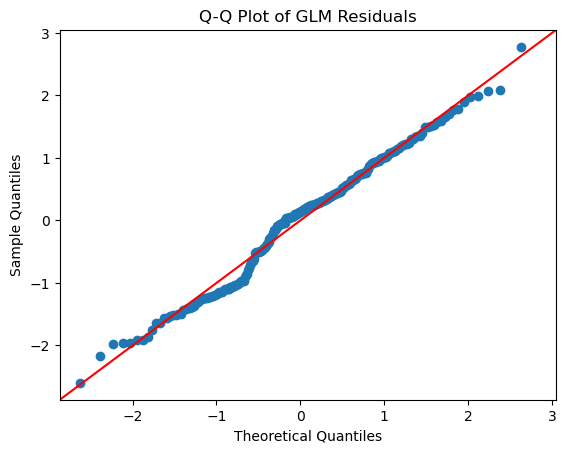

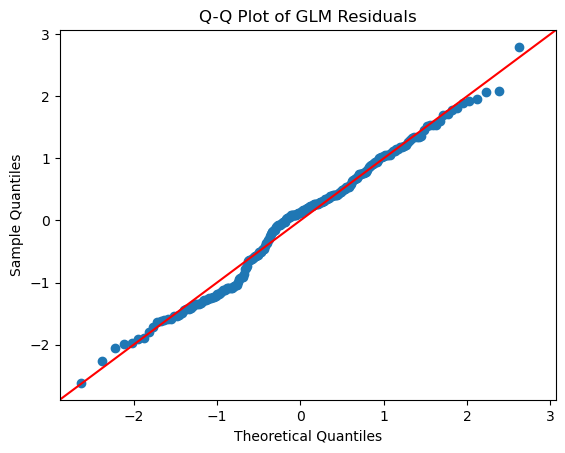


━━━ dorsal hippocampus ━━━
Fig. 4b — baseline-to-recall distance ~ context × recall status:
                   0        1                    2         3
0             Model:  MixedLM  Dependent Variable:   changes
1  No. Observations:      140              Method:      REML
2        No. Groups:        1               Scale:    0.1749
3   Min. group size:      140      Log-Likelihood:  -83.2329
4   Max. group size:      140           Converged:       Yes
5   Mean group size:    140.0                               
                                                                  Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                                                         0.770    0.125   6.185  0.000   0.526  1.014
C(dummy_context)[T.shock]                                        -0.133    0.099  -1.350  0.177  -0.326  0.060
C(dummy_context_learning)[T.RECALLER]                            -0.024    0.119  -0.204  0.839  -0.257  0.209
C(dummy_context)[T.shock]:C(dummy_co

In [4]:
stats = []

for pole in ['dorsal', 'intermediate', 'ventral']:
    stats.append("")
    stats.append("━━━ {} hippocampus ━━━".format(pole))

    # ── Fig. 4b: baseline-to-recall distance ~ context × recall status ────────
    tmp = (df_mds_ctx.query("pole == '{}'".format(pole))
           [['rat', 'cluster', 'context_learning', 'context', 'Changes(baseline-recall)', 'response']]
           .dropna()
           .rename(columns={'Changes(baseline-recall)': 'changes'}))
    tmp['dummy_context']          = ['safe' if s == 'ctrl' else 'shock' for s in tmp['context']]
    tmp['dummy_context_learning'] = ['RECALLER' if s == 'learned' else 'NON-RECALLER'
                                      for s in tmp['context_learning']]
    tmp['rat']     = tmp.rat.astype('str')
    tmp['cluster'] = tmp.cluster.astype('str')
    tmp['response'] = (tmp['response'].astype('category')
                        .cat.reorder_categories(['rest', 'ShockObs+']))

    model   = sm.MixedLM.from_formula(
        'changes ~ C(dummy_context) * C(dummy_context_learning)',
        data=tmp, groups=np.ones(tmp.shape[0]),
        vc_formula={'rat': 'C(rat)'})
    results = model.fit()
    summ    = results.summary()
    stats.append("Fig. 4b — baseline-to-recall distance ~ context × recall status:")
    stats.append(summ.tables[0].to_string())
    stats.append(summ.tables[1].to_string())

    # ── Fig. 4b: shock-responsive vs. unresponsive neurons ────────────────────
    model2   = sm.MixedLM.from_formula(
        'changes ~ C(dummy_context) * C(dummy_context_learning) * C(response)',
        data=tmp, groups=np.ones(tmp.shape[0]),
        vc_formula={'rat': 'C(rat)'})
    results2 = model2.fit()
    summ2    = results2.summary()
    stats.append("Fig. 4b — effect of ShockObs+ response on baseline-to-recall distance:")
    stats.append(summ2.tables[1].to_string())


# 3. Extract the deviance residuals
residuals = results.resid

# --- METHOD 1: Visual Inspection (Q-Q Plot) ---
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of GLM Residuals")
plt.show()


# 3. Extract the deviance residuals
residuals = results2.resid

# --- METHOD 1: Visual Inspection (Q-Q Plot) ---
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of GLM Residuals")
plt.show()


for line in stats:
    print(line)

# fig4c

/tmp/ipykernel_3500442/1012460747.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylabel='safe–shock correlation distance',
/tmp/ipykernel_3500442/1012460747.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylabel='safe–shock correlation distance',
/tmp/ipykernel_3500442/1012460747.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylabel='safe–shock correlation distance',


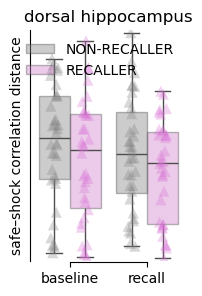

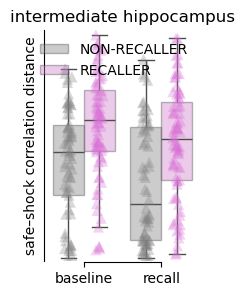

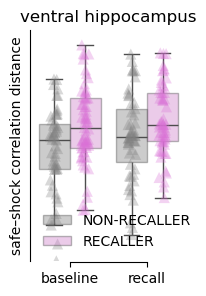

In [6]:
df_mds_ph = pd.read_parquet('Fig4c.parquet')

for pole in ['dorsal', 'intermediate', 'ventral']:
    fig, ax = plt.subplots(1, 1, figsize=(2, 3))

    sns.boxplot(x='phase', y='context_dissimilarity',
                order=['context', 'test'],
                hue='context_learning', hue_order=['not learned', 'learned'],
                palette=['gray', 'orchid'],
                boxprops=dict(alpha=0.4), fliersize=0.0,
                data=df_mds_ph.query("pole == '{}'".format(pole)), ax=ax)
    sns.stripplot(x='phase', y='context_dissimilarity',
                  order=['context', 'test'],
                  hue='context_learning', hue_order=['not learned', 'learned'],
                  palette=['gray', 'orchid'],
                  size=8, alpha=0.3, dodge=True, marker='^',
                  data=df_mds_ph.query("pole == '{}'".format(pole)), ax=ax)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], ['NON-RECALLER', 'RECALLER'], frameon=False)
    ax.set(ylabel='safe–shock correlation distance',
           yticks=[], xlabel='',
           xticklabels=['baseline', 'recall'],
           ylim=(0, 1.85),
           title='{} hippocampus'.format(pole))
    sns.despine(offset=True, trim=True)

Fig. 4c — safe–shock distance ~ phase × recall status:
                                                       Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                                              1.208    0.390   3.096  0.002   0.443   1.972
C(dummy_phase)[T.recall]                              -0.078    0.094  -0.832  0.406  -0.262   0.106
C(dummy_recall)[T.RECALLER]                           -0.463    0.226  -2.048  0.041  -0.907  -0.020
C(dummy_phase)[T.recall]:C(dummy_recall)[T.RECALLER]  -0.007    0.134  -0.052  0.958  -0.271   0.257
rat Var                                                0.142    0.267                               
Fig. 4c — safe–shock distance ~ phase × recall status:
                                                       Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                                              0.783    0.159   4.934  0.000   0.472   1.094
C(dummy_phase)[T.recall]                              -0.183    0.074  -2.492  0.0

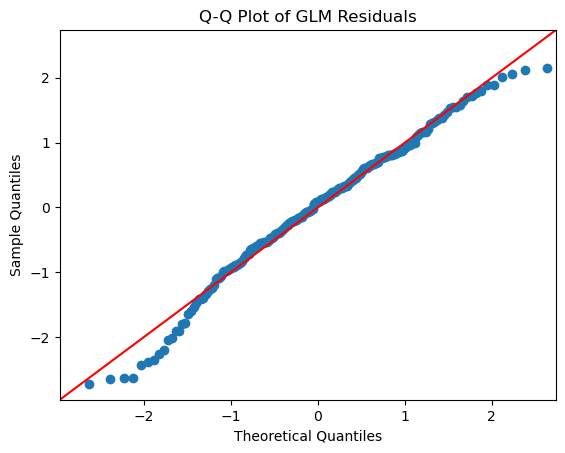

In [7]:
stats = []

for pole in ['dorsal', 'intermediate', 'ventral']:

    # ── Fig. 4c: safe–shock distance ~ phase × recall status ─────────────────
    tmp_ph = (df_mds_ph.query("pole == '{}'".format(pole))
              [['rat', 'cluster', 'context_learning', 'phase', 'context_dissimilarity']]
              .dropna())
    tmp_ph['dummy_phase']   = ['baseline' if s == 'context' else 'recall' for s in tmp_ph['phase']]
    tmp_ph['dummy_recall']  = ['RECALLER' if s == 'learned' else 'NON-RECALLER'
                                for s in tmp_ph['context_learning']]
    tmp_ph['rat']     = tmp_ph.rat.astype('str')
    tmp_ph['cluster'] = tmp_ph.cluster.astype('str')

    model3   = sm.MixedLM.from_formula(
        'context_dissimilarity ~ C(dummy_phase) * C(dummy_recall)',
        data=tmp_ph, groups=np.ones(tmp_ph.shape[0]),
        vc_formula={'rat': 'C(rat)'})
    results3 = model3.fit()
    summ3    = results3.summary()
    stats.append("Fig. 4c — safe–shock distance ~ phase × recall status:")
    stats.append(summ3.tables[1].to_string())

for line in stats:
    print(line)


# 3. Extract the deviance residuals
residuals = results3.resid

# --- METHOD 1: Visual Inspection (Q-Q Plot) ---
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of GLM Residuals")
plt.show()